# Importing the data and relevant libraries

To import the data I shall use hugginface since this is a clean and approachable way of getting the wikitext-2 which is excellent for training word classifies

In [39]:
from datasets import load_dataset

# Load the full WikiText-2 dataset
dataset = load_dataset("wikitext", "wikitext-2-v1")

print(dataset)


DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [40]:
#Store the imported data in training, test and validation sets
training_text = dataset["train"]["text"]

Here we shall import all relevant packages

In [3]:
import numpy as np
import pandas as pd
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from collections import defaultdict, Counter
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import pipeline
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import math
import pickle

# Preprocessing & Cleaning

Let us print a subsection of our text to see how it currently

In [41]:
#Let us review the data to see how its current form is
training_text[:10]

['',
 ' = Valkyria Chronicles III = \n',
 '',
 ' Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . <unk> the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " <unk> Raven " . \n',
 " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more <unk> for ser

We see that there are a large number of empty lines that we also want to remove since they provide only noise to our models. We also see that the text is currently not stored as a continous string, which is not suitable for the purpose of training our baseline models so we shall convert the text into a continous string. Furthermore, the text contains a lot of special charachters such as "= Introdction =", "<ump>" and @-@ which we also want to remove since we do not expect these provide semantic value for our models.

In [42]:
def clean_wikitext(text_lines):
    cleaned = []

    for line in text_lines:
        line = line.strip()

        # Skip empty lines
        if not line:
            continue

        # Remove section headers like "= Title ="
        if re.match(r"^=+.*=+$", line):
            continue

        # Remove <unk>
        line = line.replace("<unk>", "")

        # Replace @-@ with hyphen
        line = line.replace("@-@", "-")

        # Remove space around hyphens: "role - playing" -> "role-playing"
        line = re.sub(r"\s*-\s*", "-", line)

        # Fix spaces before punctuation: "Japan , it" -> "Japan, it"
        line = re.sub(r"\s+([,.;:!?])", r"\1", line)

        # Fix spaces after opening quotes or parentheses
        line = re.sub(r'([(\["])\s+', r"\1", line)

        # Fix spaces before closing quotes or parentheses
        line = re.sub(r'\s+([)\]"])', r"\1", line)

        # Fix multiple spaces
        line = re.sub(r"\s{2,}", " ", line)

        cleaned.append(line)

    # Join into a single text
    cleaned_corpus = " ".join(cleaned)
    cleaned_corpus = re.sub(r"\s{2,}", " ", cleaned_corpus).strip()

    return cleaned, cleaned_corpus


In [43]:
train_clean, train_corpus = clean_wikitext(dataset["train"]["text"])
val_clean, val_corpus = clean_wikitext(dataset["validation"]["text"])
test_clean, test_corpus = clean_wikitext(dataset["test"]["text"])

We print a subset of the cleaned corpus for training, validation and testing to see if our preprocessing function worked as expected

In [44]:

print(train_corpus[:200])
print(val_corpus[:200])
print(test_corpus[:200])

Senjō no Valkyria 3: Chronicles (Japanese: 戦場のヴァルキュリア3, lit. Valkyria of the Battlefield 3), commonly referred to as Valkyria Chronicles III outside Japan, is a tactical role-playing video game develo
Homarus gammarus, known as the European lobster or common lobster, is a species of lobster from the eastern Atlantic Ocean, Mediterranean Sea and parts of the Black Sea. It is closely related to the A
Robert is an English film, television and theatre actor. He had a guest-starring role on the television series The Bill in 2000. This was followed by a starring role in the play Herons written by Simo


We also print a subset of the train_clean to see if it does in fact store our cleaned text as list elements

In [45]:
train_clean[:5]

['Senjō no Valkyria 3: Chronicles (Japanese: 戦場のヴァルキュリア3, lit. Valkyria of the Battlefield 3), commonly referred to as Valkyria Chronicles III outside Japan, is a tactical role-playing video game developed by Sega and Media.Vision for the PlayStation Portable. Released in January 2011 in Japan, it is the third game in the Valkyria series. the same fusion of tactical and real-time gameplay as its predecessors, the story runs parallel to the first game and follows the"Nameless", a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit"Raven".',
 "The game began development in 2010, carrying over a large portion of the work done on Valkyria Chronicles II. While it retained the standard features of the series, it also underwent multiple adjustments, such as making the game more for series newcomers. Character designer Honjou and composer Hitoshi Sakimoto both returned from previous entries,

Our text now looks like it has been cleaned correctly and we are ready to perform additional preprocessing steps to make it suitable for the training of our models.

Note that we DO NOT remove stopwords since we want our model to be able to predict words such as a, is, the, etc. and removing stopwords would inhibit our model from learning these word patterns. Furthermore, we do not lemmatize since we do not want to change the natural form of the words. Our models should be able to distinquish between different forms of the same words since this is important in an LLM where you want to be able to communicate with it fluently.

Thus, we shall tokenize our words without performing aforementioned preprocessing steps. For this we shall utilize the keras tokenizer

In [46]:
tokenizer = Tokenizer(
    num_words=10000,        # I limit the vocabulary size to make the training of the LSTM more effecient
    lower=True,
    filters='',            # do NOT remove punctuation—we already cleaned
    oov_token="<OOV>"
)

# Fit only on training data (never on val/test)
tokenizer.fit_on_texts(train_clean)


For our N-gram model we shall create token IDs for each token in the dataset as follows

In [47]:
train_tokens = [tokenizer.texts_to_sequences([line])[0] for line in train_clean]
val_tokens  = [tokenizer.texts_to_sequences([line])[0] for line in val_clean]
test_tokens  = [tokenizer.texts_to_sequences([line])[0] for line in test_clean]


In [48]:
#we see that we have succesfully converted each word into a token with a corresponding token ID in the list sequence
print(train_tokens[:1])

[[1, 95, 3613, 3771, 3940, 1, 1, 1, 3613, 3, 2, 7888, 1, 1595, 817, 6, 10, 3613, 3940, 1221, 516, 2995, 16, 7, 5812, 8902, 236, 76, 395, 15, 1, 4, 1, 13, 2, 1446, 1, 133, 5, 202, 875, 5, 2995, 21, 16, 2, 209, 76, 5, 2, 3613, 910, 2, 128, 4791, 3, 5812, 4, 1, 3041, 10, 33, 1, 2, 380, 983, 2861, 6, 2, 31, 76, 4, 1730, 1, 7, 1, 255, 1143, 1873, 2, 2173, 3, 1, 50, 2, 91, 1, 154, 46, 1836, 1699, 320, 677, 4, 27, 1, 96, 2, 1997, 1]]


For the LSTM we want to create a sequence instead of a list of tokens since we need input-output pairs to train our model succesfully

In [49]:
def build_sequences(tokenized_lines, seq_length=15):
    X, y = [], []

    for tokens in tokenized_lines:
        # Skip lines that are too short
        if len(tokens) < 2:
            continue

        # Create sliding windows
        for i in range(1, len(tokens)):
            seq = tokens[max(0, i-seq_length):i]   # input
            target = tokens[i]                    # next word

            # Pad sequences on the left (short initial ones)
            seq = [0]*(seq_length-len(seq)) + seq

            X.append(seq)
            y.append(target)

    return np.array(X), np.array(y)


In [50]:
seq_length = 20

X_train, y_train = build_sequences(train_tokens, seq_length)
X_val,   y_val   = build_sequences(val_tokens,   seq_length)
X_test,  y_test  = build_sequences(test_tokens,  seq_length)

In [51]:
print(X_train[:5])
print(y_train[:5])

[[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    1]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    1   95]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    1   95 3613]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    1   95 3613 3771]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    1   95 3613 3771 3940]]
[  95 3613 3771 3940    1]


# Training Baseline N-gram model

Here we shall create our N-grams based on the tokenized data that we created during the preprocessing section, and based on those N-grams we shall train a classifier model to predict the next word in a given sequence.

In [56]:
#Note that chatGPT has been used to a large extent to help generate this code
from collections import defaultdict, Counter
import numpy as np
from tqdm import tqdm

class NGramModel:
    def __init__(self, n=2):  # bigram by default
        self.n = n
        self.ngram_counts = defaultdict(Counter)
        self.context_counts = Counter()
        self.vocab_size = None
        self.word_index = None

    def fit(self, tokenized_sentences, word_index):
        self.word_index = word_index
        self.vocab_size = len(word_index) + 1  # +1 for OOV

        for sentence in tokenized_sentences:
            if len(sentence) < 1:
                continue
            padded = [0]*(self.n-1) + sentence
            for i in range(len(sentence)):
                context = tuple(padded[i:i+self.n-1])
                target = padded[i+self.n-1]
                self.ngram_counts[context][target] += 1
                self.context_counts[context] += 1

    def predict_next(self, context, top_k=5):
        if len(context) != self.n-1:
            raise ValueError(f"Context length must be {self.n-1}")
        context = tuple(context)

        counts = self.ngram_counts.get(context, None)
        if counts is None:
            probs = np.ones(self.vocab_size) / self.vocab_size
        else:
            total = self.context_counts[context] + self.vocab_size
            probs = np.ones(self.vocab_size)
            for word_id, count in counts.items():
                probs[word_id] += count
            probs /= total

        top_indices = probs.argsort()[-top_k:][::-1]
        return top_indices, probs[top_indices]

def evaluate_ngram_safe(model, tokenized_sentences, top_k=3, oov_token="<OOV>", epsilon=1e-12):
    """
    Evaluate N-gram model with tqdm progress bar, Laplace smoothing, and OOV handling.
    Returns top-1 accuracy, top-k accuracy, and perplexity.
    """
    vocab_size = model.vocab_size
    oov_id = model.word_index.get(oov_token, vocab_size - 1)

    total = 0
    top1_correct = 0
    topk_correct = 0
    log_prob_sum = 0

    for sentence in tqdm(tokenized_sentences, desc="Evaluating N-gram"):
        if len(sentence) < model.n:
            continue
        padded = [0]*(model.n-1) + sentence
        for i in range(len(sentence)):
            context = tuple(padded[i:i+model.n-1])
            target = padded[i+model.n-1]

            if target >= vocab_size:
                target = oov_id

            counts = model.ngram_counts.get(context, None)
            if counts is None:
                probs = np.ones(vocab_size) / vocab_size
            else:
                total_context = model.context_counts[context] + vocab_size
                probs = np.ones(vocab_size)
                for word_id, count in counts.items():
                    probs[word_id] += count
                probs /= total_context

            top_indices = probs.argsort()[-top_k:][::-1]
            if target == top_indices[0]:
                top1_correct += 1
            if target in top_indices:
                topk_correct += 1

            log_prob_sum += np.log(probs[target] + epsilon)
            total += 1

    top1_acc = top1_correct / total
    topk_acc = topk_correct / total
    perplexity = np.exp(-log_prob_sum / total)

    return top1_acc, topk_acc, perplexity




# Training Baseline Deep Neural network

Here we shall use the created input-output sequences to train an LSTM since LSTMs are excellent for capturing information in long sequences

In [58]:
def build_lstm_model(vocab_size, seq_length, embedding_dim=32, lstm_units=32, dropout=0.2):
    """
    vocab_size: number of words in tokenizer (+1 for OOV)
    seq_length: length of input sequences
    embedding_dim: embedding vector size
    lstm_units: number of LSTM units
    dropout: dropout rate
    """
    model = Sequential()

    # Embedding layer
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=seq_length))

    # LSTM layer
    model.add(LSTM(lstm_units, return_sequences=False))
    model.add(Dropout(dropout))

    # Dense output layer
    model.add(Dense(vocab_size, activation='softmax'))

    # Compile model
    model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

    return model


In [18]:
vocab_size = len(tokenizer.word_index) + 1  # includes OOV
seq_length = 15                             # same as used in sequence pipeline

lstm_model = build_lstm_model(vocab_size, seq_length)
lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Stop if validation loss doesn't improve for 3 epochs, restore best weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# X_train, y_train, X_val, y_val already prepared
history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=10,
    verbose=1,
    callbacks=[early_stop]
)


Epoch 1/10
25743/25743 ━━━━━━━━━━━━━━━━━━━━ 726s 28ms/step - accuracy: 0.1679 - loss: 6.3172 - val_accuracy: 0.2065 - val_loss: 5.5292
Epoch 2/10
25743/25743 ━━━━━━━━━━━━━━━━━━━━ 716s 28ms/step - accuracy: 0.2077 - loss: 5.4912 - val_accuracy: 0.2146 - val_loss: 5.3448
Epoch 3/10
25743/25743 ━━━━━━━━━━━━━━━━━━━━ 713s 28ms/step - accuracy: 0.2158 - loss: 5.3073 - val_accuracy: 0.2176 - val_loss: 5.2672
Epoch 4/10
25743/25743 ━━━━━━━━━━━━━━━━━━━━ 713s 28ms/step - accuracy: 0.2216 - loss: 5.2135 - val_accuracy: 0.2186 - val_loss: 5.2234
Epoch 5/10
25743/25743 ━━━━━━━━━━━━━━━━━━━━ 731s 28ms/step - accuracy: 0.2238 - loss: 5.1590 - val_accuracy: 0.2201 - val_loss: 5.1922
Epoch 6/10
25743/25743 ━━━━━━━━━━━━━━━━━━━━ 713s 28ms/step - accuracy: 0.2255 - loss: 5.1139 - val_accuracy: 0.2211 - val_loss: 5.1728
Epoch 7/10
25743/25743 ━━━━━━━━━━━━━━━━━━━━ 715s 28ms/step - accuracy: 0.2268 - loss: 5.0826 - val_accuracy: 0.2220 - val_loss: 5.1574
Epoch 8/10
25743/25743 ━━━━━━━━━━━━━━━━━━━━ 721s 28ms/s

In [20]:
def predict_next_word(model, tokenizer, seed_text, seq_length=15, top_k=5):
    """
    Predict the next word given a seed text
    Returns top_k predictions
    """
    # Tokenize seed text
    token_list = [tokenizer.word_index.get(w.lower(), tokenizer.word_index["<OOV>"])
                  for w in seed_text.split()]

    # Pad sequence to seq_length
    token_list = [0]*(seq_length - len(token_list)) + token_list[-seq_length:]

    # Predict probabilities
    probs = model.predict(np.array([token_list]), verbose=0)[0]

    # Get top_k indices
    top_indices = probs.argsort()[-top_k:][::-1]
    top_words = [tokenizer.index_word[i] if i in tokenizer.index_word else "<OOV>" for i in top_indices]
    top_probs = probs[top_indices]

    return list(zip(top_words, top_probs))


In [21]:
seed = "The cat sat on the"
predictions = predict_next_word(lstm_model, tokenizer, seed, seq_length=15, top_k=5)
print("Next word predictions:", predictions)


Next word predictions: [('<OOV>', np.float32(0.2419825)), ('first', np.float32(0.010464548)), ('same', np.float32(0.009041973)), ('new', np.float32(0.008651692)), ('the', np.float32(0.005772844))]


# Evaluation of baseline models

Evaluation of the Bigram model

In [57]:
# Assume train_tokens is the list of tokenized sentences
# tokenizer is your fitted tokenizer

# Build bigram model
bigram = NGramModel(n=2)
bigram.fit(train_tokens, tokenizer.word_index)

# Evaluate
ngram_top1, ngram_top3, ngram_pp = evaluate_ngram_safe(bigram, test_tokens, top_k=3)
print(f"Bigram | Top-1: {ngram_top1:.4f}, Top-3: {ngram_top3:.4f}, Perplexity: {ngram_pp:.2f}")


Evaluating N-gram: 100%|██████████| 2185/2185 [22:33<00:00,  1.61it/s]

Bigram | Top-1: 0.2066, Top-3: 0.3448, Perplexity: 3426.38


Evaluation of the LSTM

In [26]:
def evaluate_lstm(model, X_test, y_test, top_k=3):
    """
    Evaluate an LSTM next-word prediction model.
    Matches the structure of your N-gram evaluation:
      - Top-1 accuracy
      - Top-k accuracy
      - Perplexity

    X_test: array of input sequences (num_samples, seq_len)
    y_test: array of target word indices (num_samples,)
    """
    total = 0
    top1_correct = 0
    topk_correct = 0
    log_prob_sum = 0

    # Loop through the test set one sample at a time
    for i in range(len(X_test)):
        # Prepare input sequence (batch size = 1)
        x = np.expand_dims(X_test[i], axis=0)  # (1, seq_len)

        # Predict probabilities over vocab
        probs = model.predict(x, verbose=0)[0]  # shape: (vocab_size,)

        target = y_test[i]  # true next token id

        # ---- Top-k evaluation ----
        # indices of top_k highest probability tokens
        top_indices = probs.argsort()[-top_k:][::-1]

        # Top-1 accuracy
        if target == top_indices[0]:
            top1_correct += 1

        # Top-k accuracy
        if target in top_indices:
            topk_correct += 1

        # ---- Perplexity ----
        # add small epsilon to avoid log(0)
        log_prob_sum += np.log(probs[target] + 1e-10)

        total += 1

    # Compute metrics
    top1_acc = top1_correct / total
    topk_acc = topk_correct / total
    perplexity = math.exp(-log_prob_sum / total)

    return top1_acc, topk_acc, perplexity


In [ ]:
# lstm_top1, lstm_top3, lstm_pp = evaluate_lstm(lstm_model, X_test, y_test, top_k=3)

# print(f"LSTM   | Top-1: {lstm_top1:.4f}, Top-3: {lstm_top3:.4f}, Perplexity: {lstm_pp:.2f}")


# Implementing a pre-trained model

For the purpose of this, we shall again use Hugginface's distilgpt since it is an excellent option for using a pretrained model to test its performance on hour wiki corpus.

In [27]:
# Use a pipeline as a high-level helper

pipe = pipeline("text-generation", model="distilbert/distilgpt2")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [28]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
model = AutoModelForCausalLM.from_pretrained("distilgpt2")




tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [29]:
print(test_clean[:2])

['Robert is an English film, television and theatre actor. He had a guest-starring role on the television series The Bill in 2000. This was followed by a starring role in the play Herons written by Simon Stephens, which was performed in 2001 at the Royal Court Theatre. He had a guest role in the television series Judge John in 2002. In 2004 landed a role as"Craig"in the episode"Teddy \'s Story"of the television series The Long Firm; he starred alongside actors Mark Strong and Derek Jacobi. He was cast in the 2005 theatre productions of the Philip Ridley play Mercury Fur, which was performed at the Drum Theatre in Plymouth and the Factory in London. He was directed by John and starred alongside Ben, Shane, Harry Kent, Fraser, Sophie Stanton and Dominic Hall.', 'In 2006, starred alongside in the play written by Mark. He appeared on a 2006 episode of the television series, Doctors, followed by a role in the 2007 theatre production of How to Curse directed by. How to Curse was performed at

Note that the training implementation of the GPT-2 model is highly inspired by code generated by chatGPT

In [30]:

def evaluate_gpt2_batch(model, tokenizer, texts, max_length=128, top_k=3, device=None):
    """
    Efficient evaluation of GPT-2 on a list of texts.
    Computes Top-1, Top-3 accuracy and perplexity.

    texts: list of strings
    max_length: max tokens per chunk
    top_k: for Top-k accuracy
    device: "cuda" or "cpu"
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model.to(device)
    model.eval()

    total_tokens = 0
    correct_top1 = 0
    correct_topk = 0
    neg_log_likelihood = 0

    for text in tqdm(texts, desc="Evaluating GPT-2"):
        # Tokenize and truncate
        input_ids = tokenizer(text, return_tensors="pt")["input_ids"][0]
        input_ids = input_ids[:max_length].to(device)

        if input_ids.size(0) < 2:
            continue  # skip too short sequences

        # Prepare context and targets in **shifted manner** (batch evaluation)
        context_ids = input_ids[:-1].unsqueeze(0)  # (1, seq_len-1)
        target_ids = input_ids[1:]                 # (seq_len-1)

        with torch.no_grad():
            outputs = model(context_ids)
            logits = outputs.logits[0]  # (seq_len-1, vocab_size)

            probs = torch.softmax(logits, dim=-1)

        # Top-k accuracy
        topk_preds = torch.topk(probs, k=top_k, dim=-1).indices  # (seq_len-1, top_k)
        top1_preds = topk_preds[:, 0]

        correct_top1 += (top1_preds == target_ids).sum().item()
        correct_topk += sum([target_ids[i].item() in topk_preds[i].tolist() for i in range(len(target_ids))])

        # Perplexity (negative log-likelihood)
        neg_log_likelihood += -torch.log(probs[range(len(target_ids)), target_ids] + 1e-12).sum().item()
        total_tokens += len(target_ids)

    top1_acc = correct_top1 / total_tokens
    topk_acc = correct_topk / total_tokens
    ppl = math.exp(neg_log_likelihood / total_tokens)

    return top1_acc, topk_acc, ppl


In [31]:
# Evaluate GPT-2 on your cleaned test corpus
gpt_top1, gpt_top3, gpt_pp = evaluate_gpt2_batch(model, tokenizer, test_clean, max_length=128, top_k=3)

print(f"GPT-2 | Top-1: {gpt_top1:.4f}, Top-3: {gpt_top3:.4f}, Perplexity: {gpt_pp:.2f}")



Evaluating GPT-2: 100%|██████████| 2185/2185 [00:30<00:00, 71.51it/s]

GPT-2 | Top-1: 0.2943, Top-3: 0.4437, Perplexity: 69.79


# Evaluation and comparison

In [61]:
results_dict = {
    "Model": ["N-gram", "LSTM", "GPT-2"],
    "Top-1 Accuracy": [ngram_top1, 0.2214, gpt_top1],
    "Top-3 Accuracy": [ngram_top3, 0.3607, gpt_top3],
    "Perplexity": [ngram_pp, 159.02, gpt_pp]
}


In [62]:
results_df = pd.DataFrame(results_dict)
results_df["Top-1 Accuracy"] = results_df["Top-1 Accuracy"].map("{:.4f}".format)
results_df["Top-3 Accuracy"] = results_df["Top-3 Accuracy"].map("{:.4f}".format)
results_df["Perplexity"] = results_df["Perplexity"].map("{:.2f}".format)


In [63]:
print(results_df)


    Model Top-1 Accuracy Top-3 Accuracy Perplexity
0  N-gram         0.2066         0.3448    3426.38
1    LSTM         0.2214         0.3607     159.02
2   GPT-2         0.2943         0.4437      69.79


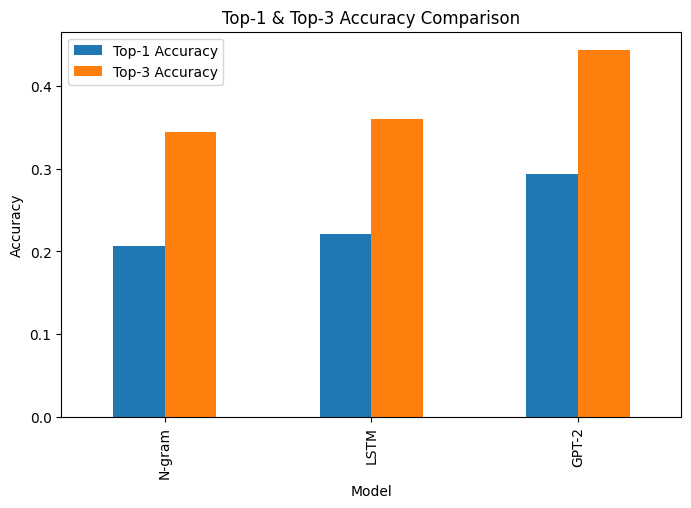

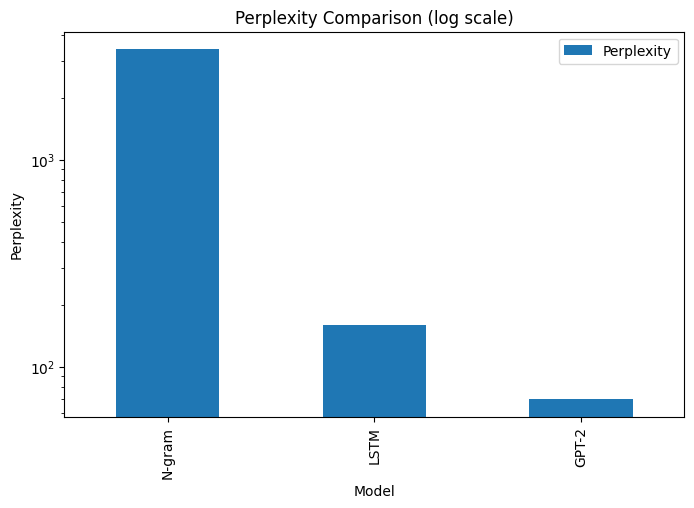

In [64]:
# Top-1 and Top-3
results_df_plot = results_df.copy()
results_df_plot[["Top-1 Accuracy", "Top-3 Accuracy"]] = results_df_plot[["Top-1 Accuracy", "Top-3 Accuracy"]].astype(float)

results_df_plot.plot(x="Model", y=["Top-1 Accuracy", "Top-3 Accuracy"], kind="bar", figsize=(8,5))
plt.title("Top-1 & Top-3 Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Perplexity (log scale)
results_df_plot["Perplexity"] = results_df_plot["Perplexity"].astype(float)
results_df_plot.plot(x="Model", y="Perplexity", kind="bar", figsize=(8,5), logy=True)
plt.title("Perplexity Comparison (log scale)")
plt.ylabel("Perplexity")
plt.show()


# Saving the models to use for the UI

In [ ]:
# with open("ngram_model.pkl", "wb") as f:
#     pickle.dump(ngram, f)


In [36]:
lstm_model.save("lstm_model.h5")


In [ ]:
# with open("tokenizer.pkl", "wb") as f:
#     pickle.dump(tokenizer, f)


In [38]:
from google.colab import files
files.download("lstm_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>